Importing plotly failed. Interactive plots will not work.


==== DC HOUSING MARKET TIME SERIES MODELING ====
Dataset shape: (89, 22)
Time range: 2001-04-01 00:00:00 to 2023-04-01 00:00:00
Target shape: (89,)
Exogenous variables shape: (89, 8)


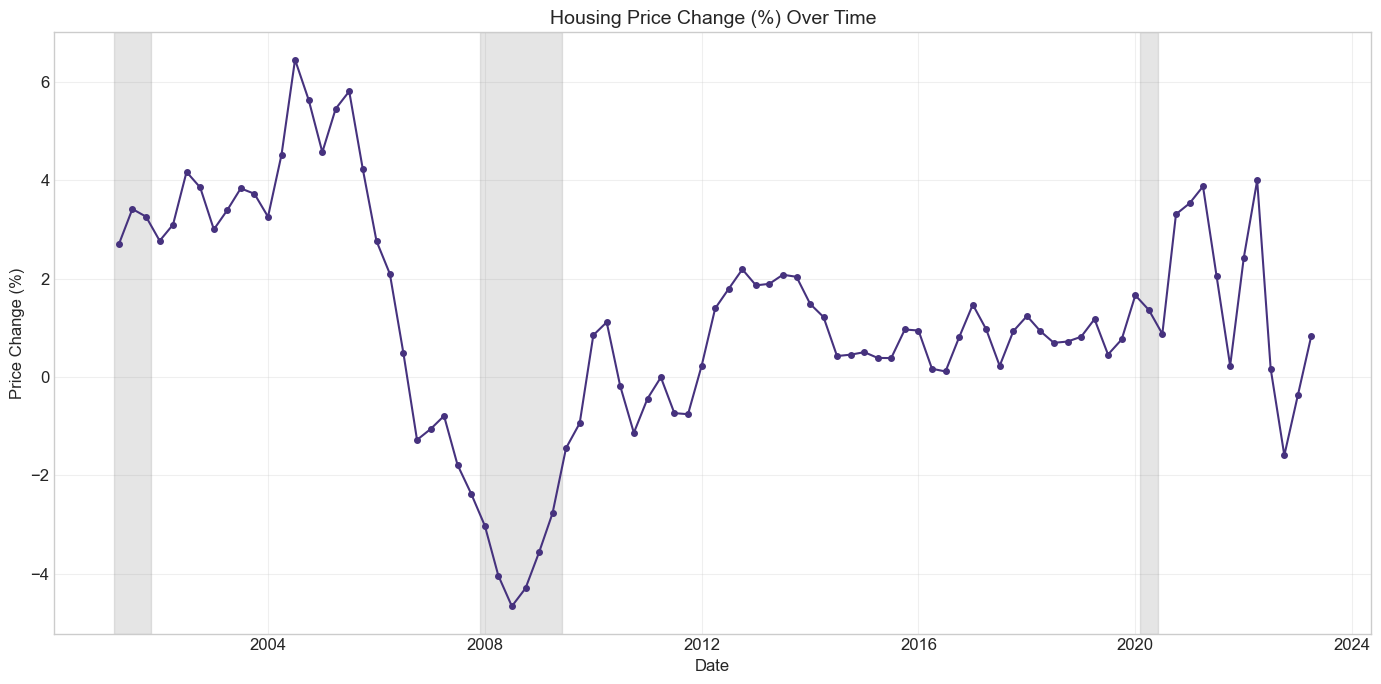

ADF Statistic: -2.5427403802492625
p-value: 0.10541833617058738
Critical Values:
	1%: -3.5148692050781247
	5%: -2.8984085156250003
	10%: -2.58643890625


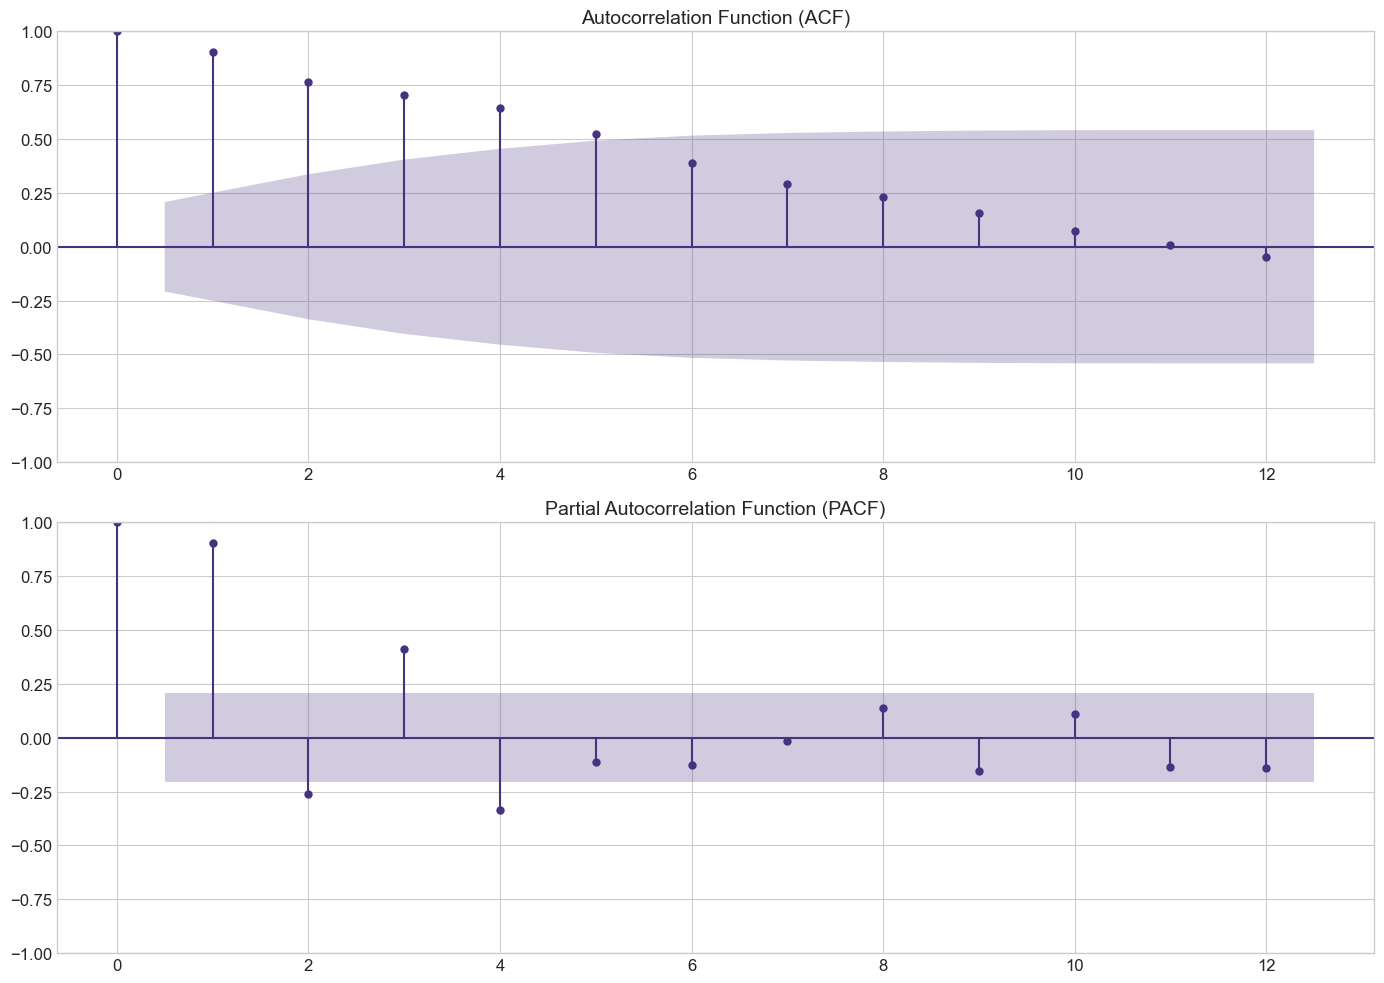

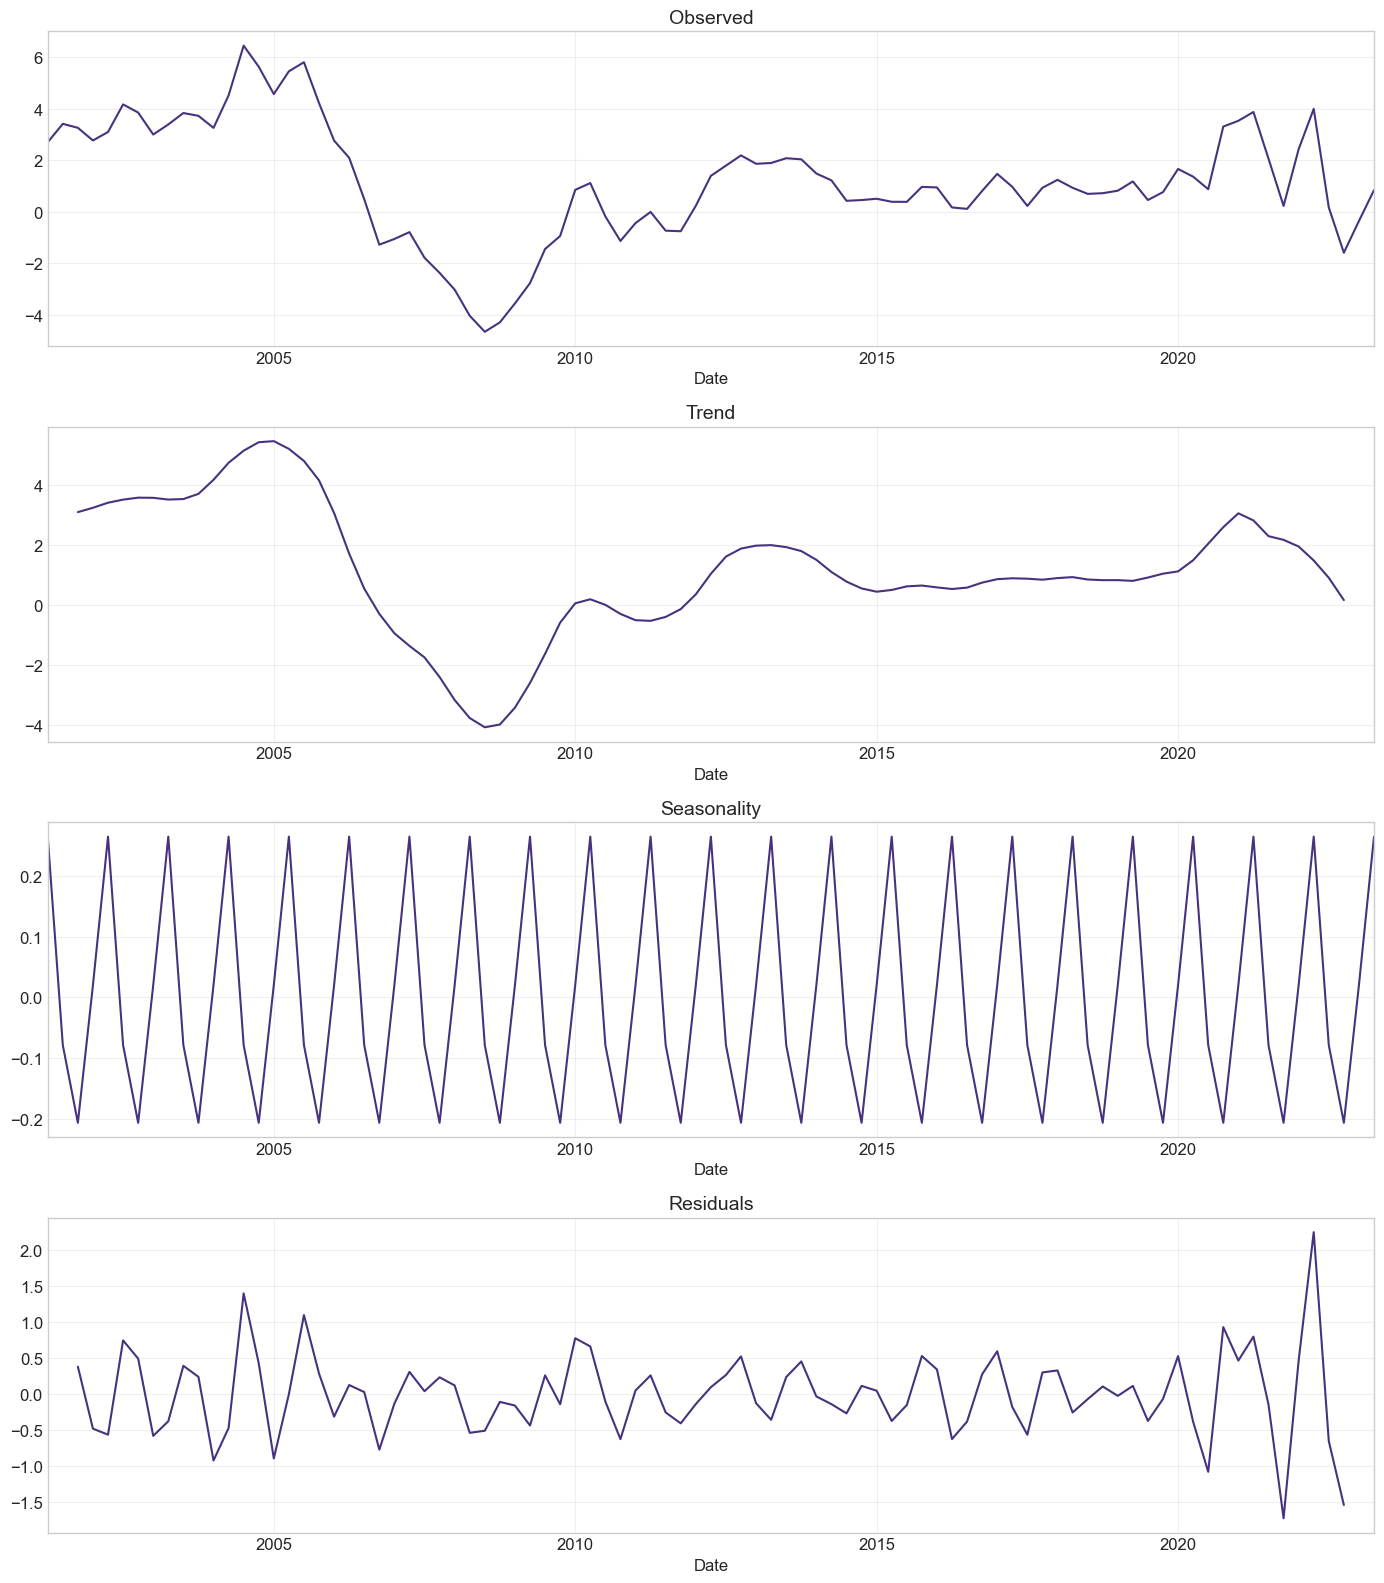


===== FINDING OPTIMAL ARIMA ORDER =====
This may take some time...
ARIMA(0,0,0) - AIC: 400.69468251984733
ARIMA(0,0,1) - AIC: 309.07535735683564
ARIMA(0,0,2) - AIC: 254.45373536692372
ARIMA(0,1,0) - AIC: 249.5504484211024
ARIMA(0,1,1) - AIC: 235.86437294768933
ARIMA(0,1,2) - AIC: 231.88969432667074
ARIMA(1,0,0) - AIC: 252.89954585230348
ARIMA(1,0,1) - AIC: 234.7606807827222
ARIMA(1,0,2) - AIC: 235.09784923139162
ARIMA(1,1,0) - AIC: 248.34783738906168
ARIMA(1,1,1) - AIC: 235.62432200387417
ARIMA(1,1,2) - AIC: 232.98611425616866
ARIMA(2,0,0) - AIC: 249.14799214631702
ARIMA(2,0,1) - AIC: 236.2593207264412
ARIMA(2,0,2) - AIC: 236.50382859283764
ARIMA(2,1,0) - AIC: 228.60771686116593
ARIMA(2,1,1) - AIC: 224.78585738706732
ARIMA(2,1,2) - AIC: 225.23636641433728
Best ARIMA order: (2, 1, 1) with AIC: 224.78585738706732

===== IMPLEMENTING ARIMAX MODEL =====
ARIMAX Model Performance:
RMSE: 2.8095
MAE: 2.2249
R²: -3.1335
Directional Accuracy: 63.79%


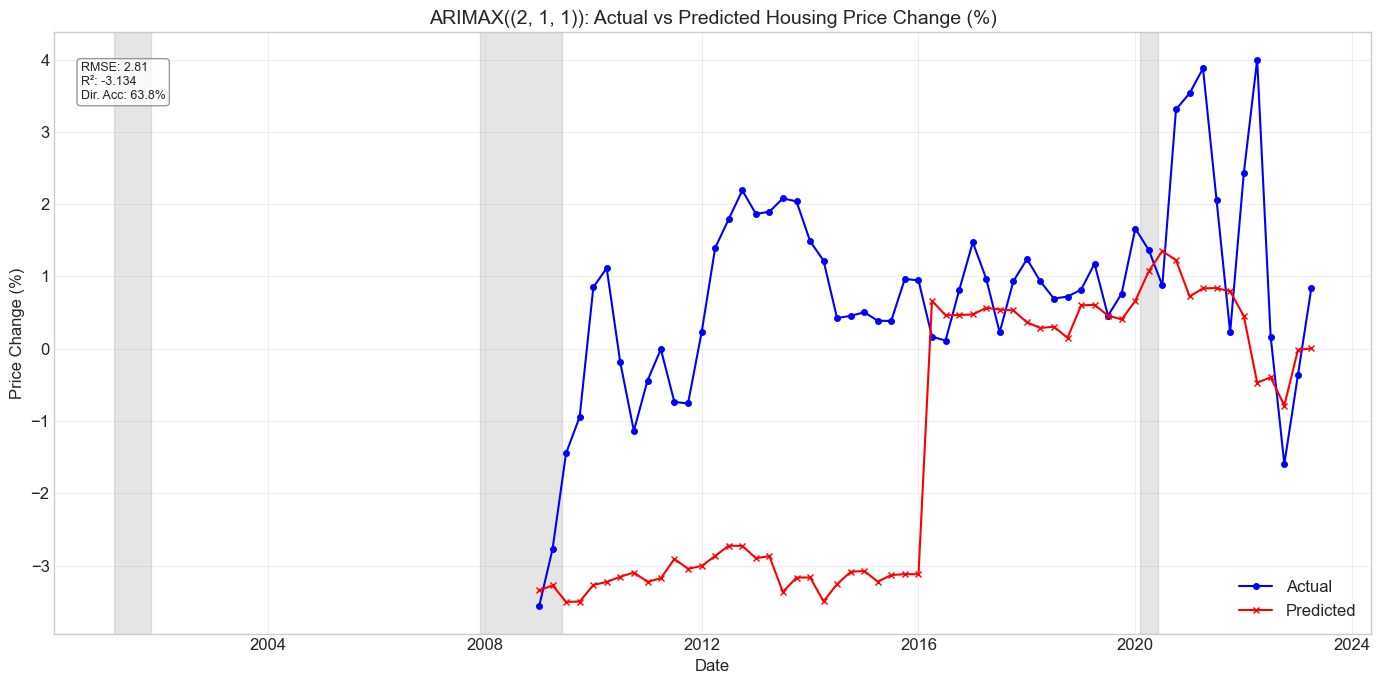

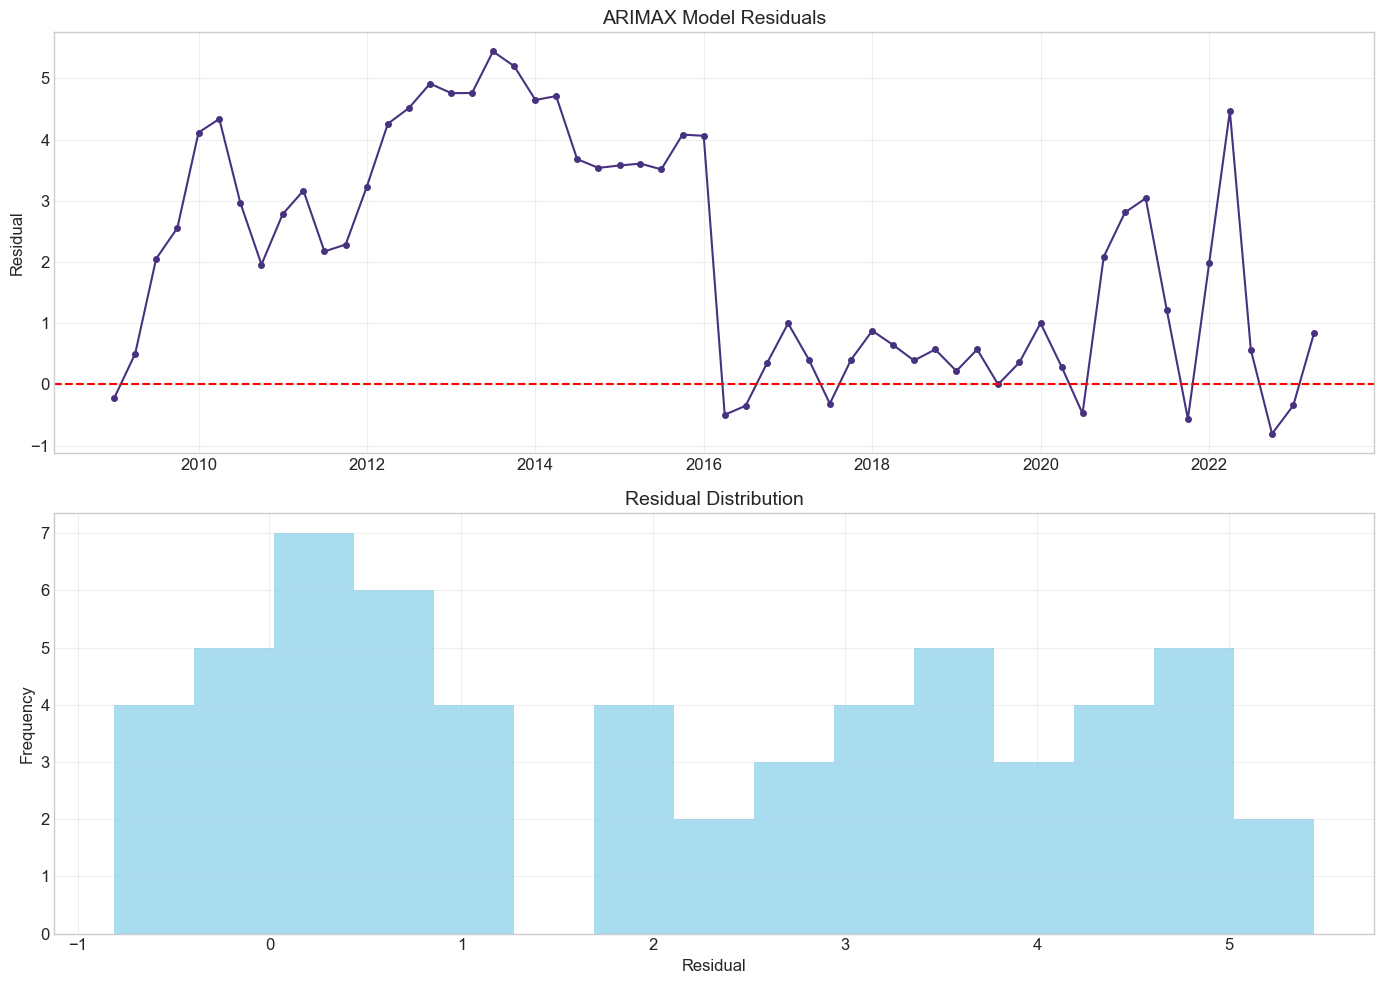

01:35:57 - cmdstanpy - INFO - Chain [1] start processing



===== IMPLEMENTING PROPHET MODEL =====


01:35:57 - cmdstanpy - INFO - Chain [1] done processing
01:35:57 - cmdstanpy - INFO - Chain [1] start processing
01:35:57 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Performance:
RMSE: 2.9913
MAE: 2.4379
R²: -3.6857
Directional Accuracy: 60.34%


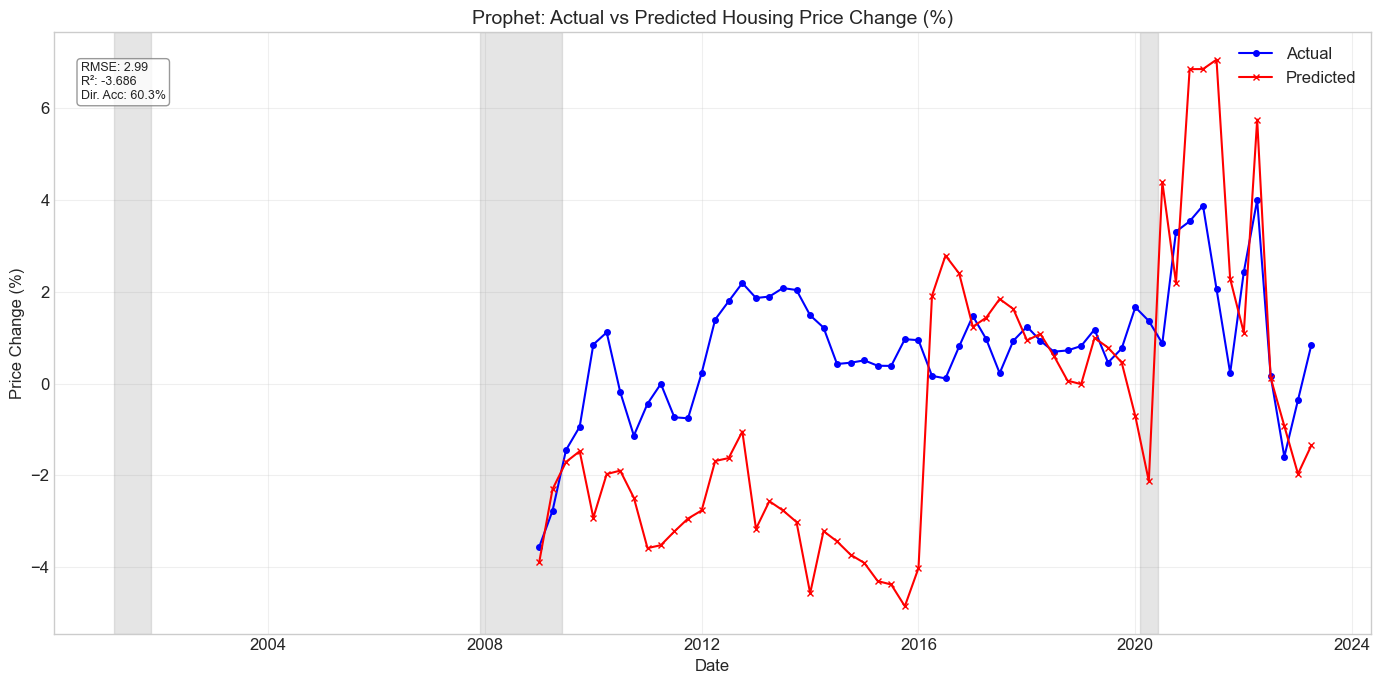

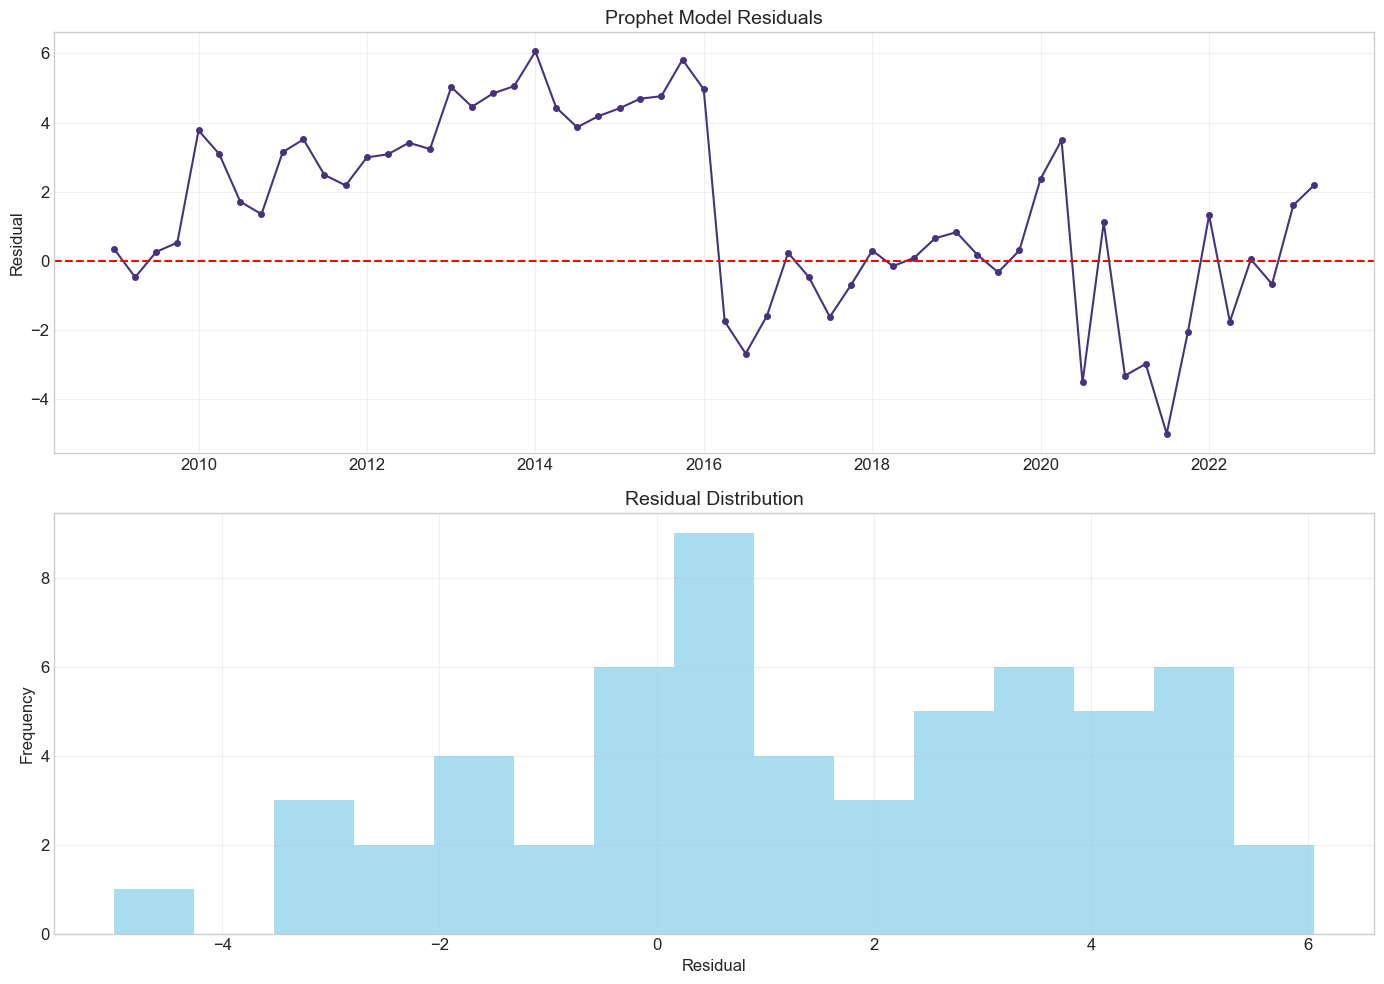


===== CREATING HYBRID FEATURES =====
Original dataframe shape: (89, 22)
Hybrid dataframe shape after adding time series features: (80, 42)
New time series features added: 20
Hybrid dataset with time series features saved to 'dc_housing_time_series_features.csv'

===== TIME SERIES MODELS PERFORMANCE COMPARISON =====
           ARIMAX   Prophet
rmse     2.809543  2.991316
mae      2.224911  2.437889
r2      -3.133527 -3.685695
dir_acc  0.637931  0.603448


In [3]:
# DC Housing Market Time Series Models
# This script implements time series specific models for the DC housing market

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# For Prophet model
try:
    from prophet import Prophet
    prophet_available = True
except ImportError:
    prophet_available = False
    print("Prophet package not available. Install with: pip install prophet")

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# -------------------------------------------------------------
# 1. Data Loading and Preparation
# -------------------------------------------------------------

def load_data():
    """Load the dataset and prepare for time series modeling"""
    # Load the clean dataset for time series models
    df = pd.read_csv('dc_housing_modeling_features_clean.csv', parse_dates=['Date'], index_col='Date')
    
    print(f"Dataset shape: {df.shape}")
    print(f"Time range: {df.index.min()} to {df.index.max()}")
    
    # The target variable is ZHVI_pct_change
    y = df['ZHVI_pct_change']
    
    # Create an exogenous variable set using the key features
    key_features = [
        'hot_market', 'recession_period', 'Interest_Rate_diff1', 
        'Mortgage_Rate_diff1', 'CPI_pct_change', 'GDP_Growth',
        'Unemployment_Rate', 'real_mortgage_rate'
    ]
    
    # Filter to ensure all selected features exist
    X = df[[col for col in key_features if col in df.columns]]
    
    print(f"Target shape: {y.shape}")
    print(f"Exogenous variables shape: {X.shape}")
    
    return df, X, y

def visualize_time_series(y):
    """Visualize the time series and its properties"""
    # Plot the original time series
    plt.figure(figsize=(14, 7))
    plt.plot(y.index, y, 'o-', markersize=4)
    plt.title('Housing Price Change (%) Over Time', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price Change (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Add recession shading
    recession_periods = [
        ('2001-03-01', '2001-11-01'),  # Dot-com bubble
        ('2007-12-01', '2009-06-01'),  # Great Recession
        ('2020-02-01', '2020-06-01')   # COVID-19 Recession
    ]
    
    for start, end in recession_periods:
        plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.2, color='gray')
    
    plt.tight_layout()
    plt.savefig('outputs/ts_price_change.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Check for stationarity
    result = adfuller(y.dropna())
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')
    
    # ACF and PACF plots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    plot_acf(y.dropna(), lags=12, ax=ax1)
    ax1.set_title('Autocorrelation Function (ACF)', fontsize=14)
    
    plot_pacf(y.dropna(), lags=12, ax=ax2)
    ax2.set_title('Partial Autocorrelation Function (PACF)', fontsize=14)
    
    plt.tight_layout()
    plt.savefig('outputs/ts_acf_pacf.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Seasonal decomposition
    try:
        decomposition = sm.tsa.seasonal_decompose(y, model='additive', period=4)  # 4 quarters per year
        
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 16))
        
        decomposition.observed.plot(ax=ax1)
        ax1.set_title('Observed', fontsize=14)
        ax1.grid(True, alpha=0.3)
        
        decomposition.trend.plot(ax=ax2)
        ax2.set_title('Trend', fontsize=14)
        ax2.grid(True, alpha=0.3)
        
        decomposition.seasonal.plot(ax=ax3)
        ax3.set_title('Seasonality', fontsize=14)
        ax3.grid(True, alpha=0.3)
        
        decomposition.resid.plot(ax=ax4)
        ax4.set_title('Residuals', fontsize=14)
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('outputs/ts_decomposition.png', dpi=300, bbox_inches='tight')
        plt.show()
    except:
        print("Could not perform seasonal decomposition - may need a longer time series")

# -------------------------------------------------------------
# 2. ARIMA / SARIMAX Modeling
# -------------------------------------------------------------

def find_optimal_arima_order(y, max_p=3, max_d=2, max_q=3):
    """Find the optimal ARIMA order using AIC"""
    best_aic = float('inf')
    best_order = None
    
    for p in range(max_p + 1):
        for d in range(max_d + 1):
            for q in range(max_q + 1):
                try:
                    model = ARIMA(y, order=(p, d, q))
                    model_fit = model.fit()
                    aic = model_fit.aic
                    
                    if aic < best_aic:
                        best_aic = aic
                        best_order = (p, d, q)
                        
                    print(f'ARIMA({p},{d},{q}) - AIC: {aic}')
                except:
                    continue
    
    print(f'Best ARIMA order: {best_order} with AIC: {best_aic}')
    return best_order

def find_optimal_sarima_order(y, max_p=2, max_d=1, max_q=2, max_P=1, max_D=1, max_Q=1, s=4):
    """Find the optimal SARIMA order using AIC"""
    best_aic = float('inf')
    best_order = None
    best_seasonal_order = None
    
    for p in range(max_p + 1):
        for d in range(max_d + 1):
            for q in range(max_q + 1):
                for P in range(max_P + 1):
                    for D in range(max_D + 1):
                        for Q in range(max_Q + 1):
                            try:
                                model = sm.tsa.statespace.SARIMAX(
                                    y,
                                    order=(p, d, q),
                                    seasonal_order=(P, D, Q, s)
                                )
                                model_fit = model.fit(disp=False)
                                aic = model_fit.aic
                                
                                if aic < best_aic:
                                    best_aic = aic
                                    best_order = (p, d, q)
                                    best_seasonal_order = (P, D, Q, s)
                                    
                                print(f'SARIMA{(p,d,q)}x{(P,D,Q,s)} - AIC: {aic}')
                            except:
                                continue
    
    print(f'Best SARIMA order: {best_order}x{best_seasonal_order} with AIC: {best_aic}')
    return best_order, best_seasonal_order

def implement_arimax_model(y, X, cv, best_order=None):
    """Implement ARIMAX model with time series cross-validation"""
    if best_order is None:
        # Default order if not provided
        best_order = (1, 1, 1)
    
    # Standardize exogenous variables
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        columns=X.columns,
        index=X.index
    )
    
    # For storing predictions
    all_y_test = []
    all_y_pred = []
    all_test_indices = []
    
    for train_idx, test_idx in cv.split(X_scaled):
        X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Train the model
        try:
            model = SARIMAX(
                y_train,
                exog=X_train,
                order=best_order,
                enforce_stationarity=False
            )
            model_fit = model.fit(disp=False)
            
            # Make predictions
            predictions = model_fit.forecast(steps=len(X_test), exog=X_test)
            
            # Store results
            all_y_test.extend(y_test)
            all_y_pred.extend(predictions)
            all_test_indices.extend(test_idx)
        except Exception as e:
            print(f"Error in fold: {e}")
            continue
    
    # Calculate performance metrics
    if len(all_y_test) > 0:
        rmse = np.sqrt(mean_squared_error(all_y_test, all_y_pred))
        mae = mean_absolute_error(all_y_test, all_y_pred)
        r2 = r2_score(all_y_test, all_y_pred)
        
        # Calculate directional accuracy
        actual_direction = np.sign(all_y_test)
        pred_direction = np.sign(all_y_pred)
        dir_acc = np.mean(actual_direction == pred_direction)
        
        print("ARIMAX Model Performance:")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        print(f"Directional Accuracy: {dir_acc:.2%}")
        
        # Create a results dataframe
        results_df = pd.DataFrame({
            'Index': X.iloc[all_test_indices].index,
            'Actual': all_y_test,
            'Predicted': all_y_pred
        }).sort_values('Index')
        
        # Plot results
        plt.figure(figsize=(14, 7))
        plt.plot(results_df['Index'], results_df['Actual'], 'o-', markersize=4, label='Actual', color='blue')
        plt.plot(results_df['Index'], results_df['Predicted'], 'x-', markersize=4, label='Predicted', color='red')
        plt.title(f'ARIMAX({best_order}): Actual vs Predicted Housing Price Change (%)', fontsize=14)
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Price Change (%)', fontsize=12)
        
        # Add recession shading
        recession_periods = [
            ('2001-03-01', '2001-11-01'),  # Dot-com bubble
            ('2007-12-01', '2009-06-01'),  # Great Recession
            ('2020-02-01', '2020-06-01')   # COVID-19 Recession
        ]
        
        for start, end in recession_periods:
            plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.2, color='gray')
        
        # Add metrics as text
        metrics_text = (f"RMSE: {rmse:.2f}\n"
                       f"R²: {r2:.3f}\n"
                       f"Dir. Acc: {dir_acc:.1%}")
        
        plt.annotate(metrics_text, xy=(0.02, 0.95), xycoords='axes fraction',
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                     fontsize=9, ha='left', va='top')
        
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('outputs/arimax_predictions.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Analyze residuals
        residuals = results_df['Actual'] - results_df['Predicted']
        
        plt.figure(figsize=(14, 10))
        plt.subplot(2, 1, 1)
        plt.plot(results_df['Index'], residuals, 'o-', markersize=4)
        plt.title('ARIMAX Model Residuals', fontsize=14)
        plt.ylabel('Residual', fontsize=12)
        plt.axhline(y=0, color='r', linestyle='--')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 1, 2)
        plt.hist(residuals, bins=15, alpha=0.7, color='skyblue')
        plt.title('Residual Distribution', fontsize=14)
        plt.xlabel('Residual', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('outputs/arimax_residuals.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        metrics = {
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'dir_acc': dir_acc
        }
        
        return results_df, metrics
    else:
        print("No valid predictions were made.")
        return None, None

# -------------------------------------------------------------
# 3. Prophet Modeling
# -------------------------------------------------------------

def implement_prophet_model(y, X, cv):
    """Implement Prophet model with exogenous regressors"""
    if not prophet_available:
        print("Prophet package not available. Install with: pip install prophet")
        return None, None
    
    # Prepare data for Prophet (requires specific format)
    prophet_data = pd.DataFrame({
        'ds': y.index,
        'y': y.values
    })
    
    # Standardize exogenous variables
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        columns=X.columns,
        index=X.index
    )
    
    # Add exogenous variables to prophet data
    for col in X_scaled.columns:
        prophet_data[col] = X_scaled[col].values
    
    # For storing predictions
    all_y_test = []
    all_y_pred = []
    all_test_indices = []
    
    for train_idx, test_idx in cv.split(prophet_data):
        train_data = prophet_data.iloc[train_idx].reset_index(drop=True)
        test_data = prophet_data.iloc[test_idx].reset_index(drop=True)
        
        # Initialize and train Prophet model
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='additive'
        )
        
        # Add exogenous regressors
        for col in X_scaled.columns:
            model.add_regressor(col)
        
        # Fit the model
        try:
            model.fit(train_data)
            
            # Create future dataframe for prediction
            future = test_data[['ds'] + list(X_scaled.columns)]
            
            # Make predictions
            forecast = model.predict(future)
            
            # Store results
            all_y_test.extend(test_data['y'])
            all_y_pred.extend(forecast['yhat'])
            all_test_indices.extend(test_idx)
        except Exception as e:
            print(f"Error in fold: {e}")
            continue
    
    # Calculate performance metrics
    if len(all_y_test) > 0:
        rmse = np.sqrt(mean_squared_error(all_y_test, all_y_pred))
        mae = mean_absolute_error(all_y_test, all_y_pred)
        r2 = r2_score(all_y_test, all_y_pred)
        
        # Calculate directional accuracy
        actual_direction = np.sign(all_y_test)
        pred_direction = np.sign(all_y_pred)
        dir_acc = np.mean(actual_direction == pred_direction)
        
        print("Prophet Model Performance:")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        print(f"Directional Accuracy: {dir_acc:.2%}")
        
        # Create a results dataframe
        results_df = pd.DataFrame({
            'Index': prophet_data.iloc[all_test_indices]['ds'],
            'Actual': all_y_test,
            'Predicted': all_y_pred
        }).sort_values('Index')
        
        # Plot results
        plt.figure(figsize=(14, 7))
        plt.plot(results_df['Index'], results_df['Actual'], 'o-', markersize=4, label='Actual', color='blue')
        plt.plot(results_df['Index'], results_df['Predicted'], 'x-', markersize=4, label='Predicted', color='red')
        plt.title('Prophet: Actual vs Predicted Housing Price Change (%)', fontsize=14)
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Price Change (%)', fontsize=12)
        
        # Add recession shading
        recession_periods = [
            ('2001-03-01', '2001-11-01'),  # Dot-com bubble
            ('2007-12-01', '2009-06-01'),  # Great Recession
            ('2020-02-01', '2020-06-01')   # COVID-19 Recession
        ]
        
        for start, end in recession_periods:
            plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.2, color='gray')
        
        # Add metrics as text
        metrics_text = (f"RMSE: {rmse:.2f}\n"
                       f"R²: {r2:.3f}\n"
                       f"Dir. Acc: {dir_acc:.1%}")
        
        plt.annotate(metrics_text, xy=(0.02, 0.95), xycoords='axes fraction',
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                     fontsize=9, ha='left', va='top')
        
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('outputs/prophet_predictions.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Analyze residuals
        residuals = results_df['Actual'] - results_df['Predicted']
        
        plt.figure(figsize=(14, 10))
        plt.subplot(2, 1, 1)
        plt.plot(results_df['Index'], residuals, 'o-', markersize=4)
        plt.title('Prophet Model Residuals', fontsize=14)
        plt.ylabel('Residual', fontsize=12)
        plt.axhline(y=0, color='r', linestyle='--')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 1, 2)
        plt.hist(residuals, bins=15, alpha=0.7, color='skyblue')
        plt.title('Residual Distribution', fontsize=14)
        plt.xlabel('Residual', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('outputs/prophet_residuals.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        metrics = {
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'dir_acc': dir_acc
        }
        
        return results_df, metrics
    else:
        print("No valid predictions were made.")
        return None, None

# -------------------------------------------------------------
# 4. Hybrid Approach: Combining Time Series and ML Models
# -------------------------------------------------------------

def create_hybrid_features(df, y, window_sizes=[2, 4, 8]):
    """Create enhanced features for a hybrid time series + ML approach"""
    df_hybrid = df.copy()
    
    # ARIMA component features
    
    # 1. Add lagged target variables
    for lag in range(1, max(window_sizes) + 1):
        df_hybrid[f'lag_{lag}'] = y.shift(lag)
    
    # 2. Add moving averages of target
    for window in window_sizes:
        df_hybrid[f'ma_{window}'] = y.rolling(window=window).mean().shift(1)
    
    # 3. Add moving standard deviations (volatility)
    for window in window_sizes:
        df_hybrid[f'std_{window}'] = y.rolling(window=window).std().shift(1)
    
    # 4. Add momentum indicators
    for window in window_sizes:
        df_hybrid[f'momentum_{window}'] = y.diff(window).shift(1)
    
    # 5. Add trend strength indicators
    for window in window_sizes:
        ma = y.rolling(window=window).mean().shift(1)
        df_hybrid[f'trend_strength_{window}'] = y / ma
    
    # Drop NA values introduced by lagging/rolling operations
    df_hybrid = df_hybrid.dropna()
    
    print(f"Original dataframe shape: {df.shape}")
    print(f"Hybrid dataframe shape after adding time series features: {df_hybrid.shape}")
    print(f"New time series features added: {df_hybrid.shape[1] - df.shape[1]}")
    
    return df_hybrid

# -------------------------------------------------------------
# 5. Main Execution Function
# -------------------------------------------------------------

def main():
    """Main execution function"""
    print("==== DC HOUSING MARKET TIME SERIES MODELING ====")
    
    # 1. Load and prepare data
    df, X, y = load_data()
    
    # 2. Visualize the time series
    visualize_time_series(y)
    
    # 3. Set up time series cross-validation
    # Use 2-fold cross-validation as established previously
    tscv = TimeSeriesSplit(n_splits=2)
    
    # 4. Find optimal ARIMA order (simplify for demonstration)
    print("\n===== FINDING OPTIMAL ARIMA ORDER =====")
    print("This may take some time...")
    try:
        best_arima_order = find_optimal_arima_order(y, max_p=2, max_d=1, max_q=2)
    except Exception as e:
        print(f"Error finding optimal ARIMA order: {e}")
        best_arima_order = (1, 1, 1)  # Default fallback
    
    # 5. Implement ARIMAX model
    print("\n===== IMPLEMENTING ARIMAX MODEL =====")
    arimax_results, arimax_metrics = implement_arimax_model(y, X, tscv, best_arima_order)
    
    # 6. Implement Prophet model
    if prophet_available:
        print("\n===== IMPLEMENTING PROPHET MODEL =====")
        prophet_results, prophet_metrics = implement_prophet_model(y, X, tscv)
    
    # 7. Create hybrid features for ensemble approach
    print("\n===== CREATING HYBRID FEATURES =====")
    df_hybrid = create_hybrid_features(df, y)
    
    # 8. Save enhanced dataset for later use
    df_hybrid.to_csv('dc_housing_time_series_features.csv')
    print(f"Hybrid dataset with time series features saved to 'dc_housing_time_series_features.csv'")
    
    # 9. Compare model performance
    if prophet_available and arimax_results is not None and prophet_results is not None:
        print("\n===== TIME SERIES MODELS PERFORMANCE COMPARISON =====")
        comparison = pd.DataFrame({
            'ARIMAX': arimax_metrics,
            'Prophet': prophet_metrics
        })
        print(comparison)
    
    return df_hybrid

if __name__ == "__main__":
    df_hybrid = main()